In [39]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
import os
import sys
import cftime
import geopandas as gp
import rioxarray
from shapely.geometry import mapping


import warnings
warnings.filterwarnings("ignore")
!conda list netcdf4

# packages in environment at /home/aelyoussoufi/miniconda3/envs/latest:
#
# Name                    Version                   Build  Channel
netcdf4                   1.7.2           nompi_py310h5146f0f_101    conda-forge


In [40]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

In [41]:
def init_climregions():
    se_dict={'name':'Southeast','short_name':'SE',
             'states':['AL','FL','GA','NC','SC','VA']}
    ne_dict={'name':'Northeast','short_name':'NE',
             'states':['CT','DE','ME','MD','MA','NH','NJ','NY','PA','RI','VT']}
    umidwest_dict={'name':'Upper Midwest','short_name':'UMW',
             'states':['IA','MI','MN','WI']}
    ohiov_dict={'name':'Ohio Valley','short_name':'OHV',
                'states':['IL','IN','KY','MI','MO','OH','TN','WV']}
    nrockies_dict={'name':'Northern Rockies and Plains','short_name':'NRP',
                   'states':['MT','NE','ND','SD','WY']}
    south_dict={'name':'South','short_name':'SOUTH',
                   'states':['AR','KS','LA','MS','OK','TX']}
    sw_dict={'name':'Southwest','short_name':'SW',
                   'states':['AZ','CO','NM','UT']}
    nw_dict={'name':'Northwest','short_name':'NW',
                   'states':['ID','OR','WA']}
    west_dict={'name':'West','short_name':'WEST',
                'states':['CA','NV']}
    


    regs_dict=[se_dict,ne_dict,umidwest_dict,ohiov_dict,nrockies_dict,south_dict,sw_dict,nw_dict,west_dict]
    
    return regs_dict



def daily_climo(da, varname, **kwargs):
    # This function calculates climatology following the SubX smoothed and periodic climatology method.
    clim_fname = kwargs.get('fname', None)
    
    # Average daily data
    da_day_clim = da.groupby('time.dayofyear').mean('time')  # Use 'time' for grouping
    
    # Rechunk for time
    da_day_clim = da_day_clim.chunk({'dayofyear': 366})
    
    # Pad the daily climatology with NaNs
    x = np.empty((366, len(da_day_clim.y), len(da_day_clim.x)))  # Use 'y' and 'x' for latitude and longitude
    x.fill(np.nan)
    _da = xr.DataArray(
        x,
        name=varname,
        coords=[np.linspace(1, 366, num=366, dtype=np.int64), da_day_clim.y, da_day_clim.x],  # Use 'y' and 'x'
        dims=da_day_clim.dims
    )
    da_day_clim_wnan = da_day_clim.combine_first(_da)
    
    # Period rolling twice to make it triangular smoothing
    da_day_clim_smooth = da_day_clim_wnan.copy()
    for i in range(2):
        # Extend the DataArray to allow rolling to be periodic
        da_day_clim_smooth = xr.concat(
            [da_day_clim_smooth[-15:], da_day_clim_smooth, da_day_clim_smooth[:15]], 'dayofyear'
        )
        # Rolling mean
        da_day_clim_smooth = da_day_clim_smooth.rolling(dayofyear=31, center=True, min_periods=1).mean()
        # Drop the periodic boundaries
        da_day_clim_smooth = da_day_clim_smooth.isel(dayofyear=slice(15, -15))
    
    # Extract the original days
    da_day_clim_smooth = da_day_clim_smooth.sel(dayofyear=da_day_clim.dayofyear)
    da_day_clim_smooth.name = varname
    ds_day_clim_smooth = da_day_clim_smooth.to_dataset()
    
    # Save to file if filename is provided, otherwise return the data
    if clim_fname:
        ds_day_clim_smooth.to_netcdf(clim_fname)
        return True
    else:
        return ds_day_clim_smooth

In [42]:
baseDir='/data/esplab/aelyoussoufi/'
dataset='snow_water_equivalent'
varname='snow_water_equivalent'
files=baseDir+'snow_water_equivalent.nc'  # File in current directory
states_shapefile='cb_2018_us_state_20m.shp'  # Shapefile in current directory
outPath = '.' 
regs_dict=init_climregions()

In [43]:
files

'/data/esplab/aelyoussoufi/snow_water_equivalent.nc'

In [44]:
ds=xr.open_mfdataset(files)
ds

<xarray.Dataset> Size: 5GB
Dimensions:                (time: 52, Y: 3351, X: 6935)
Coordinates:
  * time                   (time) object 416B 2003-12-01 00:00:00 ... 2020-12...
  * Y                      (Y) float64 27kB 24.95 24.96 24.97 ... 52.86 52.87
  * X                      (X) float64 55kB -124.7 -124.7 ... -66.95 -66.95
Data variables:
    snow_water_equivalent  (time, Y, X) float32 5GB dask.array<chunksize=(1, 3351, 6935), meta=np.ndarray>

In [45]:
ds = ds.assign_coords(longitude=(((ds.X + 180) % 360) - 180)).sortby('X')
# Rename dimensions from 'X' and 'Y' to 'x' and 'y'
ds = ds.rename({'X': 'x', 'Y': 'y'})

# Assign a CRS to the dataset (e.g., WGS84)
ds = ds.rio.write_crs("EPSG:4326")
print("Dataset CRS:", ds.rio.crs)

# Load the shapefile
states = gp.read_file(states_shapefile)

# Assign a CRS to the shapefile (e.g., WGS84)
states = states.set_crs("EPSG:4326")
print("Shapefile CRS:", states.crs)

# Reproject the dataset to match the shapefile's CRS (if necessary)
if states.crs != ds.rio.crs:
    print("Reprojecting dataset to match shapefile CRS...")
    ds = ds.rio.reproject(states.crs)


Dataset CRS: EPSG:4326
Shapefile CRS: EPSG:4326


In [46]:

states = states.set_crs("EPSG:4326")
print("Shapefile CRS:", states.crs)
if states.crs != ds.rio.crs:
    print("Reprojecting dataset to match shapefile CRS...")
    ds = ds.rio.reproject(states.crs)

Shapefile CRS: EPSG:4326


In [47]:
# Create a mask for all states at once
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50
mask = us_states.mask(ds.x, ds.y)  # Use 'x' and 'y' for longitude and latitude

# Mask the SWE data
swe_us = ds[varname].where(mask >= 0)

In [48]:
# Initialize a list to store state-level SWE values
state_swe_values = []

# Loop through each state and compute the mean SWE
for state in states.itertuples():
    print(f"Processing state: {state.STUSPS}")
    
    try:
        # Clip the SWE data to the state's geometry
        state_geometry = state.geometry
        swe_clipped = swe_us.rio.clip([state_geometry], states.crs, drop=True)
        
        # Check if the clipped data is empty
        if swe_clipped.isnull().all():
            print(f"No data found for state: {state.STUSPS}. Skipping...")
            continue
        
        # Print the dimensions of the clipped data for debugging
        print(f"Dimensions of clipped data for {state.STUSPS}: {swe_clipped.dims}")
        
        # Compute the mean SWE for the state, reducing all relevant dimensions
        if 'time' in swe_clipped.dims:
            state_mean_swe = float(swe_clipped.mean(dim=['y', 'x', 'time']).values)
        else:
            state_mean_swe = float(swe_clipped.mean(dim=['y', 'x']).values)
        
        # Append the result to the list
        state_swe_values.append({'State': state.STUSPS, 'SWE': state_mean_swe})
    
    except Exception as e:
        print(f"Error processing state {state.STUSPS}: {e}. Skipping...")
        continue

# Convert the list to a DataFrame
state_swe_df = pd.DataFrame(state_swe_values)

# Drop rows with NaN SWE values (e.g., for regions outside the US)
state_swe_df = state_swe_df.dropna(subset=['SWE'])

Processing state: MD
Dimensions of clipped data for MD: ('time', 'y', 'x')
Processing state: IA
Dimensions of clipped data for IA: ('time', 'y', 'x')
Processing state: DE
Dimensions of clipped data for DE: ('time', 'y', 'x')
Processing state: OH
Dimensions of clipped data for OH: ('time', 'y', 'x')
Processing state: PA
Dimensions of clipped data for PA: ('time', 'y', 'x')
Processing state: NE
Dimensions of clipped data for NE: ('time', 'y', 'x')
Processing state: WA
Dimensions of clipped data for WA: ('time', 'y', 'x')
Processing state: PR
Error processing state PR: No data found in bounds. Data variable: snow_water_equivalent. Skipping...
Processing state: AL
Dimensions of clipped data for AL: ('time', 'y', 'x')
Processing state: AR
Dimensions of clipped data for AR: ('time', 'y', 'x')
Processing state: NM
Dimensions of clipped data for NM: ('time', 'y', 'x')
Processing state: TX
Dimensions of clipped data for TX: ('time', 'y', 'x')
Processing state: CA
Dimensions of clipped data for 

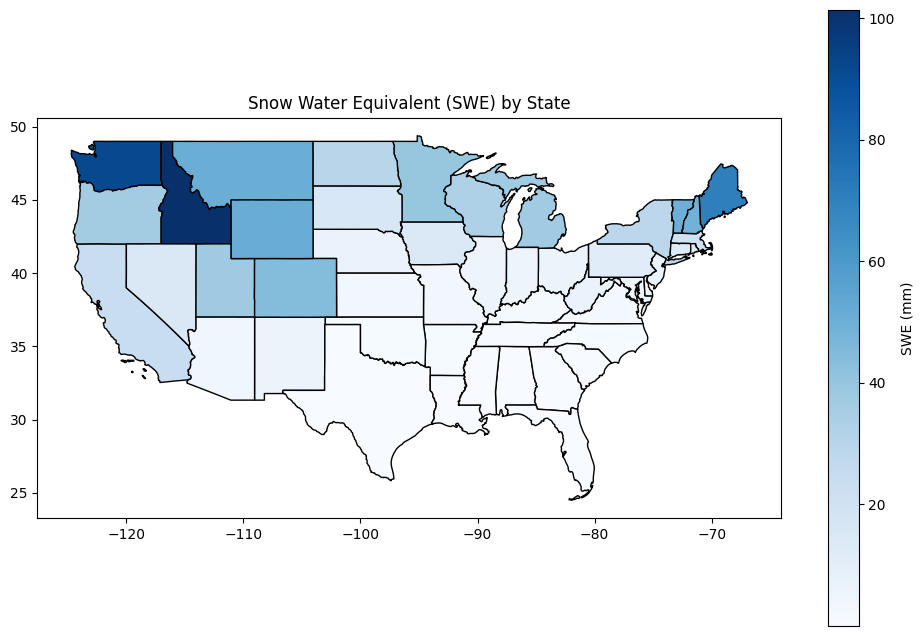

In [49]:
# Merge the SWE data with the states GeoDataFrame
states_with_swe = states.merge(state_swe_df, left_on='STUSPS', right_on='State')
# Plot the choropleth map
fig, ax = plt.subplots(figsize=(12, 8))
states_with_swe.plot(column='SWE', ax=ax, legend=True,
                     cmap='Blues', edgecolor='black',
                     legend_kwds={'label': "SWE (mm)"})
plt.title('Snow Water Equivalent (SWE) by State')
plt.show()


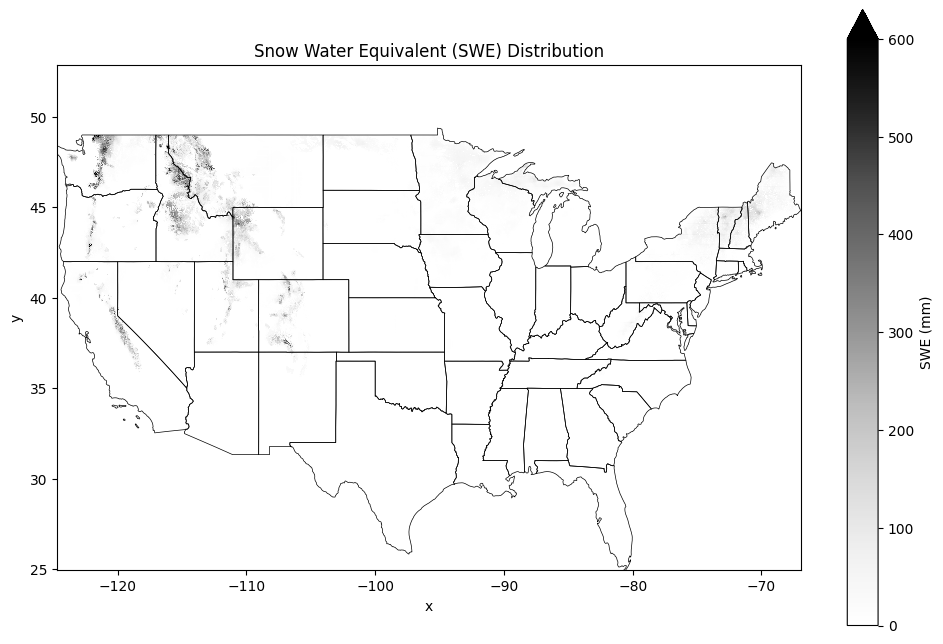

In [50]:
# Create a mask for all states at once
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50
mask = us_states.mask(ds.x, ds.y)  # Use 'x' and 'y' for longitude and latitude

# Mask the SWE data
swe_us = ds[varname].where(mask >= 0)


# Plot the SWE distribution at each grid point
fig, ax = plt.subplots(figsize=(12, 8))
swe_us.isel(time=0).plot(ax=ax, cmap='Greys', add_colorbar=True, cbar_kwargs={'label': 'SWE (mm)'}, vmin=0, vmax=600)
states.boundary.plot(ax=ax, color='black', linewidth=0.5)  # Add state boundaries for reference
plt.title('Snow Water Equivalent (SWE) Distribution')
plt.show()



In [51]:
swe_us

<xarray.DataArray 'snow_water_equivalent' (time: 52, y: 3351, x: 6935)> Size: 5GB
dask.array<where, shape=(52, 3351, 6935), dtype=float32, chunksize=(1, 3351, 6935), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) object 416B 2003-12-01 00:00:00 ... 2020-12-01 00:00:00
  * y            (y) float64 27kB 24.95 24.96 24.97 24.98 ... 52.85 52.86 52.87
  * x            (x) float64 55kB -124.7 -124.7 -124.7 ... -66.96 -66.95 -66.95
    longitude    (x) float64 55kB -124.7 -124.7 -124.7 ... -66.96 -66.95 -66.95
    spatial_ref  int64 8B 0
Attributes:
    units:      mm
    long_name:  Snow Water Equivalent

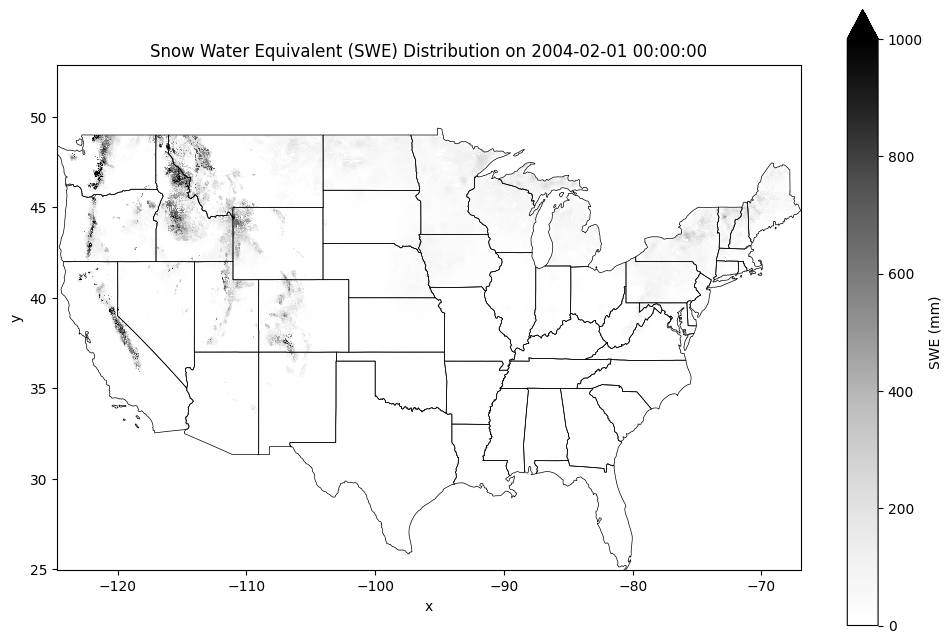

In [53]:


# Define the specific time using cftime.Datetime360Day
specific_time = cftime.Datetime360Day(2004, 2, 1, has_year_zero=True)

# Select the SWE data for the specific time
swe_specific_time = swe_us.sel(time=specific_time, method='nearest')  # Use 'nearest' to handle slight mismatches

# Plot the SWE distribution for the specific time
fig, ax = plt.subplots(figsize=(12, 8))
swe_specific_time.plot(ax=ax, cmap='Greys', add_colorbar=True, cbar_kwargs={'label': 'SWE (mm)'}, vmin=0, vmax=1000)
states.boundary.plot(ax=ax, color='black', linewidth=0.5)  # Add state boundaries for reference
plt.title(f'Snow Water Equivalent (SWE) Distribution on {specific_time}')
plt.show()

In [ ]:
ds_us=ds.sel(Y=slice(25,50),X=slice(-125,-50)).compute()
ds_us=ds_us.rename({'Y':'lat','X':'lon'})

In [ ]:
#for state_num,abbrv in zip(states.index.values,states['STUSPS'].values):

    #print(abbrv)
    
   # ds_state=ds_us.where(ds_us['mask']==state_num,drop=True).compute()
    
    #if (len(ds_state['lat'])>0 and len(ds_state['lon']>0)):
    
        #ds_climo=daily_climo(ds_state['snow_water_equivalent'],'snow_water_equivalent')['snow_water_equivalent'].chunk({'dayofyear':366,'lat':'auto','lon':'auto'})
       # ds_anoms=ds_state['snow_water_equivalent'].groupby('time.dayofyear')-ds_climo
       # outfile='../swe.2003-01-01.2020-12-31.'+abbrv+'.nc'
       # ds_anoms.to_netcdf(outfile)

In [ ]:
#for state_num,abbrv in zip(states.index.values,states['STUSPS'].values):

    print(abbrv)
    
    ds_state=ds_us.where(ds_us['mask']==state_num,drop=True).compute()
    
    if (len(ds_state['lat'])>0 and len(ds_state['lon']>0)):
    
        ds_climo=daily_climo(ds_state['snow_water_equivalent'],'snow_water_equivalent')['snow_water_equivalent'].chunk({'dayofyear':366,'lat':'auto','lon':'auto'})
        ds_anoms=ds_state['snow_water_equivalent'].groupby('time.dayofyear')-ds_climo
        outfile='../swe.2003-01-01.2020-12-31.'+abbrv+'.nc'
        ds_anoms.to_netcdf(outfile)